In [28]:
# Import de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from scipy.stats import skew, kurtosis


In [29]:
# path a los archivos parquet
##files = glob.glob("../dataset/*.parquet")
files = glob.glob("../dataset/06-new-variables/yellow_tripdata_2024-01.parquet")
# leer .parquet files y concatenar en un solo df 
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print(len(files), "files merged")
print(df.shape)

# Formato de visualización de floats en pandas
pd.set_option('display.float_format', '{:.2f}'.format)

1 files merged
(2567535, 25)


In [30]:
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day
df['pickup_hr'] = df['tpep_pickup_datetime'].dt.hour
df['weekday'] = df['tpep_pickup_datetime'].dt.weekday # monday = 0, sunday = 6

df['dropoff_day'] = df['tpep_dropoff_datetime'].dt.day
df['dropoff_hr'] = df['tpep_dropoff_datetime'].dt.hour

df['revenue'] = df['fare_amount'] + df['tip_amount']

df.head(2)

,vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,ratecode,payment_type,fare_amount,extra,mta_tax,tip_amount,...,pickup_hour,hour_bin,log_trip_distance,total_amount_calculated,pickup_day,pickup_hr,weekday,dropoff_day,dropoff_hr,revenue
0,"Curb Mobility, LLC",2024-01-01 00:57:55,2024-01-01 01:17:43,1,Standard rate,Cash,17.70,1.00,0.50,0.00,...,0,0-2,1.00,22.70,1,0,0,1,1,17.70
1,"Creative Mobile Technologies, LLC",2024-01-01 00:03:00,2024-01-01 00:09:36,1,Standard rate,Credit card,10.00,3.50,0.50,3.75,...,0,0-2,1.03,21.25,1,0,0,1,0,13.75


In [31]:
df.drop(columns=['pickup_borough', 'dropoff_borough', 'dropoff_service_zone', 'pickup_service_zone','vendor', 'passenger_count', 'ratecode', 'payment_type', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'hour_bin', 'log_trip_distance', 'total_amount_calculated'], inplace=True)
df.head(2)

,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_zone,dropoff_zone,pickup_hour,pickup_day,pickup_hr,weekday,dropoff_day,dropoff_hr,revenue
0,17.70,1.00,0.50,0.00,0.00,1.00,22.70,2.50,0.00,Penn Station/Madison Sq West,East Village,0,1,0,0,1,1,17.70
1,10.00,3.50,0.50,3.75,0.00,1.00,21.25,2.50,0.00,Lenox Hill East,Upper East Side North,0,1,0,0,1,0,13.75


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2567535 entries, 0 to 2567534
Data columns (total 18 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   fare_amount            float64 
 1   extra                  float64 
 2   mta_tax                float64 
 3   tip_amount             float64 
 4   tolls_amount           float64 
 5   improvement_surcharge  float64 
 6   total_amount           float64 
 7   congestion_surcharge   float64 
 8   Airport_fee            float64 
 9   pickup_zone            category
 10  dropoff_zone           category
 11  pickup_hour            int32   
 12  pickup_day             int32   
 13  pickup_hr              int32   
 14  weekday                int32   
 15  dropoff_day            int32   
 16  dropoff_hr             int32   
 17  revenue                float64 
dtypes: category(2), float64(10), int32(6)
memory usage: 264.5 MB


In [33]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import f_oneway

# -----------------------------------------------------------
# 1. Separar features numéricas y categóricas
# -----------------------------------------------------------

target = "pickup_zone"

numeric_features = df.select_dtypes(include=["float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["category", "object", "int32", "int64"]).columns.tolist()

# Excluir la target de ambos
if target in numeric_features:
    numeric_features.remove(target)
if target in categorical_features:
    categorical_features.remove(target)

print("Features numéricas:", numeric_features)
print("Features categóricas:", categorical_features)


Features numéricas: ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'revenue']
Features categóricas: ['dropoff_zone', 'pickup_hour', 'pickup_day', 'pickup_hr', 'weekday', 'dropoff_day', 'dropoff_hr']


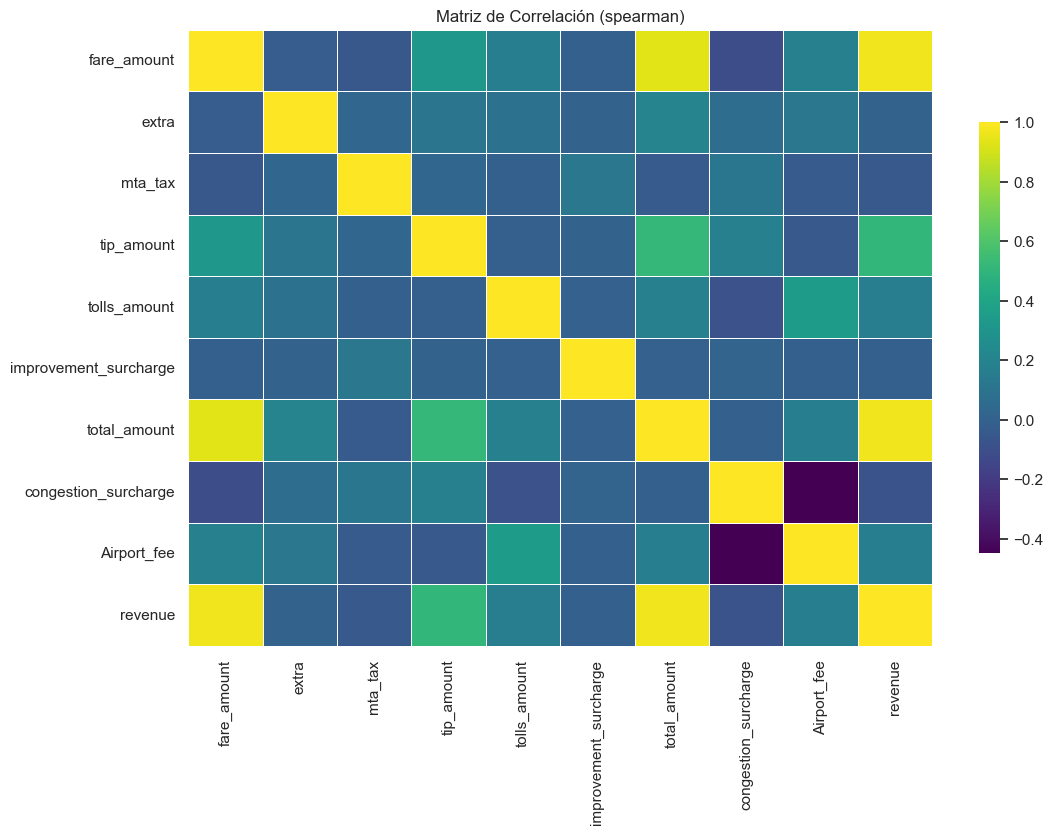

Información Mutua:


,feature,mutual_info
6,total_amount,0.15
7,congestion_surcharge,0.13
9,revenue,0.13
8,Airport_fee,0.10
1,extra,0.09
0,fare_amount,0.09
3,tip_amount,0.08
2,mta_tax,0.02
4,tolls_amount,0.02
5,improvement_surcharge,0.01


C:\Users\pc\AppData\Local\Temp\ipykernel_12348\1805716046.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="mutual_info", y="feature", palette="viridis")


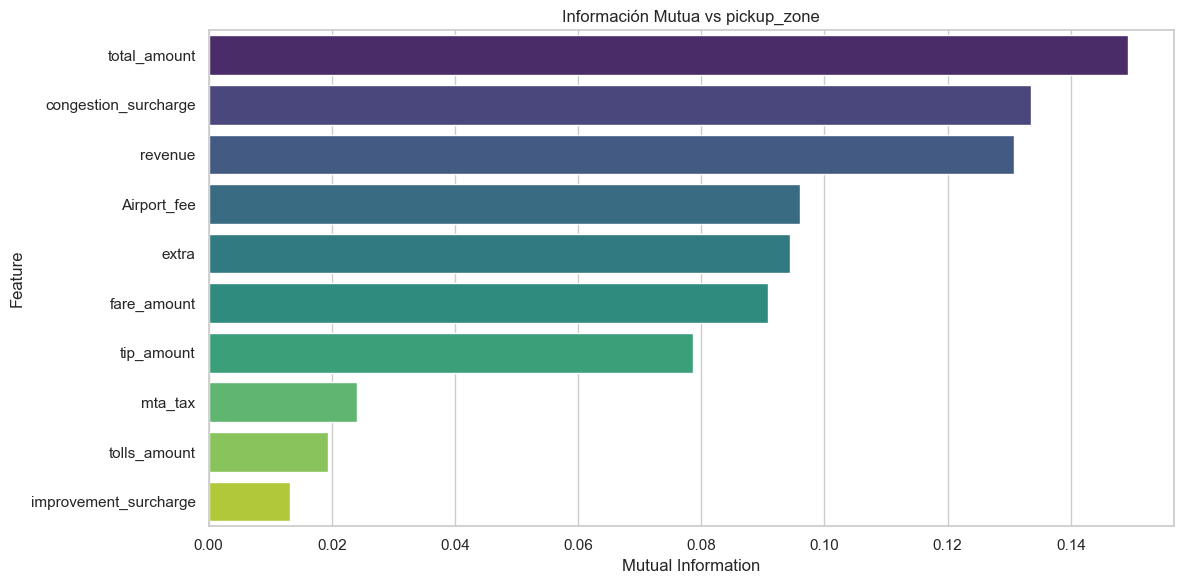

In [34]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de gráficos
sns.set(style="whitegrid", palette="viridis")


# -----------------------------------------------------------
# 2. Correlación de Pearson entre numéricas
# -----------------------------------------------------------

corr_matrix = df[numeric_features].corr(method="spearman")

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix, annot=False, cmap="viridis", 
    linewidths=0.5, cbar_kws={"shrink": 0.7}
)
plt.title("Matriz de Correlación (spearman)")
plt.show()

# -----------------------------------------------------------
# 3. Información Mutua (numéricas → target categórica)
# -----------------------------------------------------------

X = df[numeric_features]
y = df[target]

mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42)

mi_df = pd.DataFrame({
    "feature": numeric_features,
    "mutual_info": mi_scores
}).sort_values(by="mutual_info", ascending=False)

print("Información Mutua:")
display(mi_df)

# ---- Gráfico MI ----
plt.figure(figsize=(12, 6))
sns.barplot(data=mi_df, x="mutual_info", y="feature", palette="viridis")
plt.title("Información Mutua vs pickup_zone")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



In [35]:
from sklearn.feature_selection import mutual_info_classif

target = "pickup_zone"

# Features categóricas
categorical_features = df.select_dtypes(include=["category", "object"]).columns.tolist()
categorical_features = [c for c in categorical_features if c != target]

# one-hot encoding temporal solo para X
X_cat = pd.get_dummies(df[categorical_features], drop_first=False)

# Información mutua
mi_cat_scores = mutual_info_classif(X_cat, df[target], discrete_features=True, random_state=42)

mi_cat_df = pd.DataFrame({
    "feature": X_cat.columns,
    "mutual_info": mi_cat_scores
}).sort_values(by="mutual_info", ascending=False)

display(mi_cat_df)


KeyboardInterrupt: 

In [ ]:
# numéricas contra target categórica

from scipy.stats import f_oneway
import pandas as pd
import numpy as np

target = "pickup_zone"

# Features numéricas
numeric_features = df.select_dtypes(include=["float64", "int32", "int64"]).columns.tolist()
numeric_features = [c for c in numeric_features if c != target]

anova_results = []

# categorías de la target
categories = df[target].unique()

for col in numeric_features:
    # valores por categoría
    groups = [df[df[target] == cat][col].dropna().values for cat in categories]
    
    # ANOVA
    f_stat, p_val = f_oneway(*groups)
    anova_results.append((col, f_stat, p_val))

anova_df = pd.DataFrame(anova_results, columns=["feature", "F_statistic", "p_value"])
anova_df = anova_df.sort_values(by="p_value")

display(anova_df)

import seaborn as sns
import matplotlib.pyplot as plt

# Barplot F-statistic
plt.figure(figsize=(10, 6))
sns.barplot(data=anova_df.sort_values("F_statistic", ascending=False),
            x="F_statistic", y="feature", palette="viridis")
plt.title("ANOVA — F-statistic por feature")
plt.tight_layout()
plt.show()

# Barplot p-values en escala log
anova_plot = anova_df.copy()
anova_plot["log_p"] = -np.log10(anova_plot["p_value"])

plt.figure(figsize=(10, 6))
sns.barplot(data=anova_plot.sort_values("log_p", ascending=False),
            x="log_p", y="feature", palette="viridis")
plt.title("ANOVA — -log10(p-value) por feature")
plt.tight_layout()
plt.show()
